# Hello MLlib K-means clustering

In [94]:
# Prereqquisites
from pyspark.sql import SparkSession

In [95]:
# Spark Session and Context
spark = SparkSession.builder.master("local") \
        .appName("Simple MLlib K-means clusters") \
        .getOrCreate()
print("Spark Version: ", spark.version)

Spark Version:  3.4.1


In [98]:
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.clustering import KMeans
from pyspark.sql.functions import col
import matplotlib.pyplot as plt


# Example data for clustering
data = [
    (1, 2.0, 3.0),
    (2, 2.1, 3.1),
    (3, 4.0, 6.0),
    (4, 4.1, 6.1),
    (5, 10.0, 10.0),
    (6, 10.1, 10.1),
]
columns = ["id", "x", "y"]

# Create a DataFrame
df = spark.createDataFrame(data, columns)

df.show()

+---+----+----+
| id|   x|   y|
+---+----+----+
|  1| 2.0| 3.0|
|  2| 2.1| 3.1|
|  3| 4.0| 6.0|
|  4| 4.1| 6.1|
|  5|10.0|10.0|
|  6|10.1|10.1|
+---+----+----+



In [99]:
# Assemble features into a single vector
assembler = VectorAssembler(inputCols=["x", "y"], outputCol="features")
df_vector = assembler.transform(df)

# Scale features
scaler = StandardScaler(inputCol="features", outputCol="scaled_features", withStd=True, withMean=False)
scaled_data = scaler.fit(df_vector).transform(df_vector)

# Apply KMeans clustering
kmeans = KMeans(featuresCol="scaled_features", k=3, seed=42)  # k=3 clusters
kmeans_model = kmeans.fit(scaled_data)
clustered_data = kmeans_model.transform(scaled_data)

# Show cluster assignments
clustered_data.select("id", "x", "y", "prediction").show()

+---+----+----+----------+
| id|   x|   y|prediction|
+---+----+----+----------+
|  1| 2.0| 3.0|         1|
|  2| 2.1| 3.1|         1|
|  3| 4.0| 6.0|         2|
|  4| 4.1| 6.1|         2|
|  5|10.0|10.0|         0|
|  6|10.1|10.1|         0|
+---+----+----+----------+



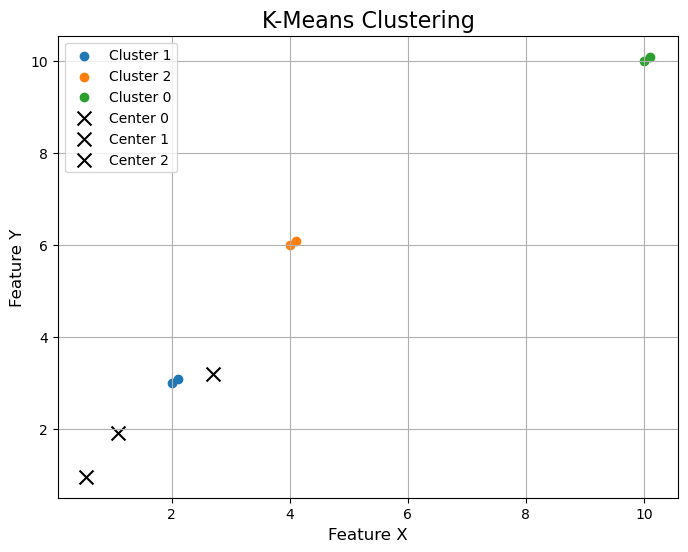

In [100]:

# Collect cluster data for visualization
clustered_pd = clustered_data.select("x", "y", "prediction").toPandas()

# Visualize the clusters
plt.figure(figsize=(8, 6))
for cluster in clustered_pd["prediction"].unique():
    cluster_points = clustered_pd[clustered_pd["prediction"] == cluster]
    plt.scatter(cluster_points["x"], cluster_points["y"], label=f"Cluster {cluster}")

# Add cluster centers
centers = kmeans_model.clusterCenters()
for idx, center in enumerate(centers):
    plt.scatter(center[0], center[1], c="black", marker="x", s=100, label=f"Center {idx}")

# Customize the plot
plt.title("K-Means Clustering", fontsize=16)
plt.xlabel("Feature X", fontsize=12)
plt.ylabel("Feature Y", fontsize=12)
plt.legend()
plt.grid()
plt.show()

### Same with 5 features

+---+--------------------+----------+
| id|            features|prediction|
+---+--------------------+----------+
|  1|[2.0,3.0,4.0,5.0,...|         1|
|  2|[2.1,3.1,4.1,5.1,...|         1|
|  3|[4.0,6.0,7.0,8.0,...|         2|
|  4|[4.1,6.1,7.1,8.1,...|         2|
|  5|[10.0,10.0,11.0,1...|         0|
|  6|[10.1,10.1,11.1,1...|         0|
+---+--------------------+----------+



NameError: name 'Vectors' is not defined

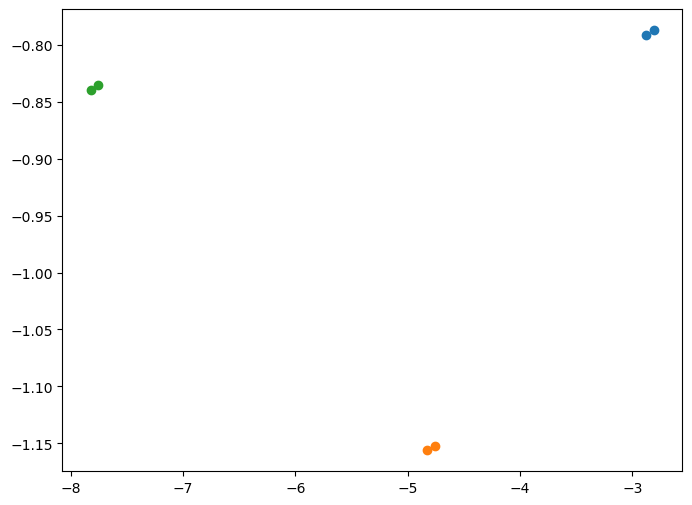

In [101]:
from pyspark.ml.feature import PCA

# Example data for clustering with 5 features
data = [
    (1, 2.0, 3.0, 4.0, 5.0, 6.0),
    (2, 2.1, 3.1, 4.1, 5.1, 6.1),
    (3, 4.0, 6.0, 7.0, 8.0, 9.0),
    (4, 4.1, 6.1, 7.1, 8.1, 9.1),
    (5, 10.0, 10.0, 11.0, 12.0, 13.0),
    (6, 10.1, 10.1, 11.1, 12.1, 13.1),
]
columns = ["id", "feature1", "feature2", "feature3", "feature4", "feature5"]

# Create a DataFrame
df = spark.createDataFrame(data, columns)

# Assemble features into a single vector
assembler = VectorAssembler(inputCols=["feature1", "feature2", "feature3", "feature4", "feature5"], outputCol="features")
df_vector = assembler.transform(df)

# Scale features
scaler = StandardScaler(inputCol="features", outputCol="scaled_features", withStd=True, withMean=False)
scaled_data = scaler.fit(df_vector).transform(df_vector)

# Apply KMeans clustering
kmeans = KMeans(featuresCol="scaled_features", k=3, seed=42)  # k=3 clusters
kmeans_model = kmeans.fit(scaled_data)
clustered_data = kmeans_model.transform(scaled_data)

# Show cluster assignments
clustered_data.select("id", "features", "prediction").show()

# Reduce dimensions using PCA for visualization
pca = PCA(k=2, inputCol="scaled_features", outputCol="pca_features")
pca_model = pca.fit(clustered_data)
pca_data = pca_model.transform(clustered_data)

# Collect PCA-transformed data for plotting
pca_pd = pca_data.select("pca_features", "prediction").toPandas()
pca_pd["x"] = pca_pd["pca_features"].apply(lambda vec: vec[0])
pca_pd["y"] = pca_pd["pca_features"].apply(lambda vec: vec[1])

# Visualize the clusters in 2D
plt.figure(figsize=(8, 6))
for cluster in pca_pd["prediction"].unique():
    cluster_points = pca_pd[pca_pd["prediction"] == cluster]
    plt.scatter(cluster_points["x"], cluster_points["y"], label=f"Cluster {cluster}")

# Add cluster centers
centers = kmeans_model.clusterCenters()
centers_pca = pca_model.transform(spark.createDataFrame([(Vectors.dense(c),) for c in centers], ["scaled_features"]))
centers_pd = centers_pca.select("pca_features").toPandas()
plt.scatter(centers_pd["x"], centers_pd["y"], c="black", marker="x", s=100, label="Centers")

# Customize the plot
plt.title("K-Means Clustering with 5 Features (PCA Projection)", fontsize=16)
plt.xlabel("PCA Component 1", fontsize=12)
plt.ylabel("PCA Component 2", fontsize=12)
plt.legend()
plt.grid()
plt.show()
